In [1]:
# Copyright 2026 International Business Machines

# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at

#  http://www.apache.org/licenses/LICENSE-2.0

# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

# Terrakit: Labels to dataset pipeline for Salt Marsh dataset preparation

This notebook demonstrates generating a ML-ready dataset from a collection of labels.

In [ ]:
import os
import terrakit

from terrakit.general_utils import plotting
from create_salt_marsh_labels_csv import marsh_labels_to_csv

# Set LOGLEVEL to info for less verbose logging
os.environ["LOGLEVEL"] = "WARNING"

In [2]:
!terrakit --version

terrakit 0.1.8.post1


## 1. Process labels


In [3]:
# Set a working directory, a dataset name and a directory where some labels can be found
DATASET_NAME = "s2_saltmarsh_test_single"
WORKING_DIR = f"./tmp/{DATASET_NAME}"
# LABELS_FOLDER = "./labels"
LABELS_FOLDER = "./data_minimal/train/labels"
# LABELS_FOLDER = "./data/train/labels"

In [4]:
marsh_labels_to_csv(LABELS_FOLDER)

Created ./data_minimal/train/labels/metadata.csv
testing
filename,date
saltmarsh_category_April2019_tile_24_9_tile_0_0_lab.tif,2019-04-15
saltmarsh_category_April2019_tile_24_9_tile_1_0_lab.tif,2019-04-15


<!--
 Copyright (c) 2026 Copyright 2024 IBM Corp
 
 This software is released under the MIT License.
 https://opensource.org/licenses/MIT
-->



#

In [6]:
# Process the labels by providing a labels folder, working directory and dataset name.
labels_gdf, grouped_bbox_gdf = terrakit.process_labels(
    labels_folder=LABELS_FOLDER,
    dataset_name=DATASET_NAME,
    working_dir=WORKING_DIR,
    label_type="raster", # Can be raster or vector labels
    datetime_info="csv" # Datetime information is provided in csv format
)

2026-06-08 09:22:01 [INFO    ] Processing labels with arguments: {'labels_folder': './data_minimal/train/labels', 'dataset_name': 's2_saltmarsh_test_single', 'working_dir': './tmp/s2_saltmarsh_test_single', 'active': True, 'label_type': 'raster', 'datetime_info': 'csv'} (labels.py:521)
2026-06-08 09:22:01 [INFO    ] Processing with parent arguments: dataset_name='s2_saltmarsh_test_single' working_dir=PosixPath('tmp/s2_saltmarsh_test_single') (pipeline_model.py:104)
2026-06-08 09:22:01 [INFO    ] Processing labels with arguments: labels_folder=PosixPath('data_minimal/train/labels') active=True label_type='raster' datetime_info='csv' (labels.py:473)
2026-06-08 09:22:01 [INFO    ] Setting datetime to 2019-04-15 and label class to 1 for saltmarsh_category_April2019_tile_24_9_tile_1_0_lab.tif. (labels.py:337)
2026-06-08 09:22:01 [INFO    ] Successfully processed ./data_minimal/train/labels/saltmarsh_category_April2019_tile_24_9_tile_1_0_lab.tif (labels.py:344)
2026-06-08 09:22:01 [INFO    ]

#

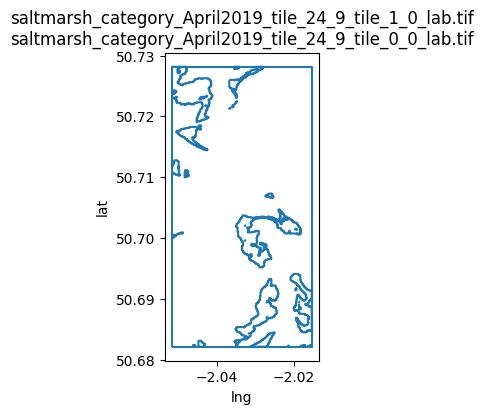

In [7]:
# Plot the process labels and bboxes to confirm they appear as expected.
plotting.plot_label_dataframes(labels_gdf, grouped_bbox_gdf)

In [39]:
# Additionally plot labels and bbox on map.
map_collection, title_list = plotting.plot_labels_on_map(labels_gdf, grouped_bbox_gdf)
for i in range(0, len(map_collection)):
    print(title_list[i])
    display(map_collection[i])



Download tile bounding box and labels for: saltmarsh_category_April2019_tile_24_9_tile_1_0_lab.tif,saltmarsh_category_April2019_tile_24_9_tile_0_0_lab.tif



#

## 2. Download the data

In [45]:
config = {
    "download": {
        "data_sources": [
            {
                "data_connector": "sentinel_aws",
                "collection_name": "sentinel-2-l2a",
                "bands": ["blue", "green", "red", "nir"], # six bands # 
            },
        ],
        "date_allowance": {"pre_days": 30, "post_days": 30},
        "transform": {
            "scale_data_xarray": False, # Should be false
            "impute_nans": False,
            "reproject": False,
        },
        "max_cloud_cover": 80,
    },
}

queried_data = terrakit.download_data(
    data_sources=config["download"]["data_sources"],
    date_allowance=config["download"]["date_allowance"],
    transform=config["download"]["transform"],
    max_cloud_cover=config["download"]["max_cloud_cover"],
    dataset_name=DATASET_NAME,
    working_dir=WORKING_DIR,
    keep_files=True,
)

2026-06-08 10:06:53 [INFO    ] Processing download_data with arguments: {'data_sources': [{'data_connector': 'sentinel_aws', 'collection_name': 'sentinel-2-l2a', 'bands': ['blue', 'green', 'red', 'nir']}], 'date_allowance': {'pre_days': 30, 'post_days': 30}, 'transform': {'scale_data_xarray': False, 'impute_nans': False, 'reproject': False}, 'dataset_name': 's2_saltmarsh_test_single', 'working_dir': './tmp/s2_saltmarsh_test_single', 'active': True, 'max_cloud_cover': 80, 'datetime_bbox_shp_file': './tmp/terrakit_curated_dataset_all_bboxes.shp', 'labels_shp_file': './tmp/terrakit_curated_dataset_labels.shp', 'keep_files': True, 'set_no_data': False} (download_data.py:621)
2026-06-08 10:06:53 [INFO    ] Processing with parent arguments: dataset_name='s2_saltmarsh_test_single' working_dir=PosixPath('tmp/s2_saltmarsh_test_single') (pipeline_model.py:104)
2026-06-08 10:06:53 [INFO    ] Processing download_data with arguments: {'pipeline_model': PipelineModel(dataset_name='s2_saltmarsh_test_

[                                        ] | 0% Completed | 241.71 us

2026-06-08 10:06:58 [WARNING ] CPLE_NotSupported in warp options does not support option SHARING (rio_reader.py:352)
2026-06-08 10:06:58 [WARNING ] CPLE_NotSupported in warp options does not support option SHARING (rio_reader.py:352)
2026-06-08 10:06:58 [WARNING ] CPLE_NotSupported in warp options does not support option SHARING (rio_reader.py:352)
2026-06-08 10:06:58 [WARNING ] CPLE_NotSupported in warp options does not support option SHARING (rio_reader.py:352)
2026-06-08 10:06:58 [WARNING ] CPLE_NotSupported in warp options does not support option SHARING (rio_reader.py:352)
2026-06-08 10:06:58 [WARNING ] CPLE_NotSupported in warp options does not support option SHARING (rio_reader.py:352)
2026-06-08 10:06:58 [WARNING ] CPLE_NotSupported in warp options does not support option SHARING (rio_reader.py:352)
2026-06-08 10:06:58 [WARNING ] CPLE_NotSupported in warp options does not support option SHARING (rio_reader.py:352)


[########################################] | 100% Completed | 3.18 ss


2026-06-08 10:07:01 [INFO    ] Saving cloud optimized geotiff to tmp/s2_saltmarsh_test_single/sentinel_aws_sentinel-2-l2a_2019-04-12.tif (geodata_utils.py:492)
2026-06-08 10:07:01 [INFO    ] Set band descriptions: ['blue', 'green', 'red', 'nir'] (geodata_utils.py:543)
2026-06-08 10:07:01 [INFO    ] Saving cloud optimized geotiff to tmp/s2_saltmarsh_test_single/sentinel_aws_sentinel-2-l2a_2019-04-12.tif (geodata_utils.py:492)
2026-06-08 10:07:02 [INFO    ] Set band descriptions: ['blue', 'green', 'red', 'nir'] (geodata_utils.py:543)
2026-06-08 10:07:02 [INFO    ] Queried data: ['tmp/s2_saltmarsh_test_single/sentinel_aws_sentinel-2-l2a_2019-04-12.tif'] (download_data.py:355)
2026-06-08 10:07:02 [INFO    ] Rasterizing vectors to the queried data (download_data.py:375)
2026-06-08 10:07:02 [INFO    ] Label classes being used: [1] (download_data.py:380)
2026-06-08 10:07:02 [INFO    ] Writing to tmp/s2_saltmarsh_test_single/sentinel_aws_sentinel-2-l2a_2019-04-12_label.tif (download_data.py:42

#

In [76]:
from importlib import reload
import terrakit.download.data_connectors.sentinel_aws
reload(terrakit.download.data_connectors.sentinel_aws)
import terrakit.download.download_data
reload(terrakit.download.download_data)
import terrakit.general_utils.plotting
reload(terrakit.general_utils.plotting)
import terrakit
reload(terrakit)



<module 'terrakit' from '/Users/rosielickorish/Documents/IBMResearch/2026/terrakit/terrakit/__init__.py'>

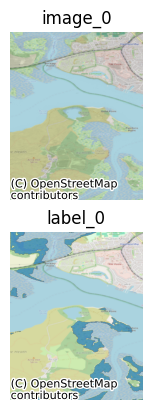

Legend
image_0: sentinel_aws_sentinel-2-l2a_2019-04-12.tif, label_0: sentinel_aws_sentinel-2-l2a_2019-04-12_label.tif
---


In [77]:
plotting.plot_tiles_and_label_pair(
    queried_data, bands=config["download"]["data_sources"][0]["bands"]
) # TODO: plot tile and label pairs not so good

In [56]:
import terrakit.chip.tiling
# import terrakit.download.download_data
# import terrakit.download_data
reload(terrakit.chip.tiling)
# reload(terrakit.download.download_data)
# reload(terrakit.download_data)


<module 'terrakit.chip.tiling' from '/Users/rosielickorish/Documents/IBMResearch/2026/terrakit/terrakit/chip/tiling.py'>

In [57]:
# Copyright (c) 2026 Copyright 2024 IBM Corp
# 
# This software is released under the MIT License.
# https://opensource.org/licenses/MIT

queried_data

['tmp/s2_saltmarsh_test_single/sentinel_aws_sentinel-2-l2a_2019-04-12.tif']

Continue here.... the label file is not being found. TerraKit is looking in the working dir, not the label dir

#

In [58]:
chip_args = {
    "chip": {"sample_dim": 256},
    # "data_suffix": "_imputed.tif"        # Use imputed S2 data
    "data_suffix": ".tif",
    "label_suffix": "_label.tif",           # Terrakit creates a new label file from your label and gives in the suffix _label.tif
    "chip_suffix": "_chip.tif",           # Output S2 chip suffix
    "chip_label_suffix": "_chip_lab.tif" # Output label chip suffix
}

res = terrakit.chip_and_label_data(
    dataset_name=DATASET_NAME,
    sample_dim=chip_args["chip"]["sample_dim"],
    queried_data=queried_data,
    working_dir=WORKING_DIR,
    data_suffix=chip_args["data_suffix"],
    label_suffix="_label.tif",
    chip_suffix=chip_args["chip_suffix"],
    chip_label_suffix=chip_args["chip_label_suffix"],
)
#   data_suffix: "_imputed.tif"        # Use imputed S2 data
#   label_suffix: "_lab.tif"      \     # Your label file suffix
#   chip_suffix: "_chip.tif"           # Output S2 chip suffix
#   chip_label_suffix: "_chip_lab.tif" # Output label chip suffix

2026-06-08 10:56:45 [INFO    ] Processing labels with arguments: {'dataset_name': 's2_saltmarsh_test_single', 'working_dir': './tmp/s2_saltmarsh_test_single', 'active': True, 'data_suffix': '.tif', 'label_suffix': '_label.tif', 'chip_suffix': '_chip.tif', 'chip_label_suffix': '_chip_lab.tif', 'sample_dim': 256, 'queried_data': ['tmp/s2_saltmarsh_test_single/sentinel_aws_sentinel-2-l2a_2019-04-12.tif'], 'keep_files': True, 'match_suffix': True, 'stats': True} (tiling.py:493)
2026-06-08 10:56:45 [INFO    ] Processing with parent arguments: dataset_name='s2_saltmarsh_test_single' working_dir=PosixPath('tmp/s2_saltmarsh_test_single') (pipeline_model.py:104)
2026-06-08 10:56:45 [INFO    ] Chipping data with arguments: active=True data_suffix='.tif' label_suffix='_label.tif' chip_suffix='_chip.tif' chip_label_suffix='_chip_lab.tif' sample_dim=256 queried_data=['tmp/s2_saltmarsh_test_single/sentinel_aws_sentinel-2-l2a_2019-04-12.tif'] keep_files=True match_suffix=True (tiling.py:439)
2026-06-

Reloading chip and label


  0%|          | 0/1 [00:00<?, ?it/s]2026-06-08 10:56:45 [INFO    ] .tif (tiling.py:287)
2026-06-08 10:56:45 [INFO    ] tmp/s2_saltmarsh_test_single/sentinel_aws_sentinel-2-l2a_2019-04-12.tif (tiling.py:288)
2026-06-08 10:56:45 [INFO    ] tmp/s2_saltmarsh_test_single/sentinel_aws_sentinel-2-l2a_2019-04-12 (tiling.py:289)
2026-06-08 10:56:45 [INFO    ] tmp/s2_saltmarsh_test_single/sentinel_aws_sentinel-2-l2a_2019-04-12_label.tif (tiling.py:290)
2026-06-08 10:56:45 [INFO    ] tmp/s2_saltmarsh_test_single/sentinel_aws_sentinel-2-l2a_2019-04-12 (tiling.py:291)
2026-06-08 10:56:45 [INFO    ] Chipping data: tmp/s2_saltmarsh_test_single/sentinel_aws_sentinel-2-l2a_2019-04-12.tif (tiling.py:298)
2026-06-08 10:56:45 [INFO    ] Chipping label data: tmp/s2_saltmarsh_test_single/sentinel_aws_sentinel-2-l2a_2019-04-12_label.tif (tiling.py:329)
100%|██████████| 1/1 [00:00<00:00,  4.44it/s]
2026-06-08 10:56:45 [INFO    ] finished chipping ['tmp/s2_saltmarsh_test_single/sentinel_aws_sentinel-2-l2a_201

In [67]:
import terrakit.general_utils.plotting
from terrakit.general_utils import plotting
reload(terrakit.general_utils.plotting)
import terrakit
reload(terrakit)

<module 'terrakit' from '/Users/rosielickorish/Documents/IBMResearch/2026/terrakit/terrakit/__init__.py'>

!!!
t
chip_suffix: _chip.tif
chip_label_suffix: _chip_lab.tif
['tmp/s2_saltmarsh_test_single/sentinel_aws_sentinel-2-l2a_2019-04-12_0_chip.tif', 'tmp/s2_saltmarsh_test_single/sentinel_aws_sentinel-2-l2a_2019-04-12_1_chip.tif']
2
2


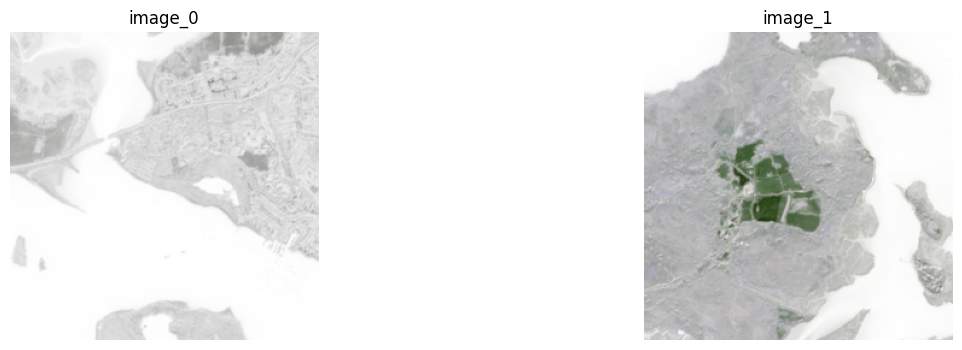

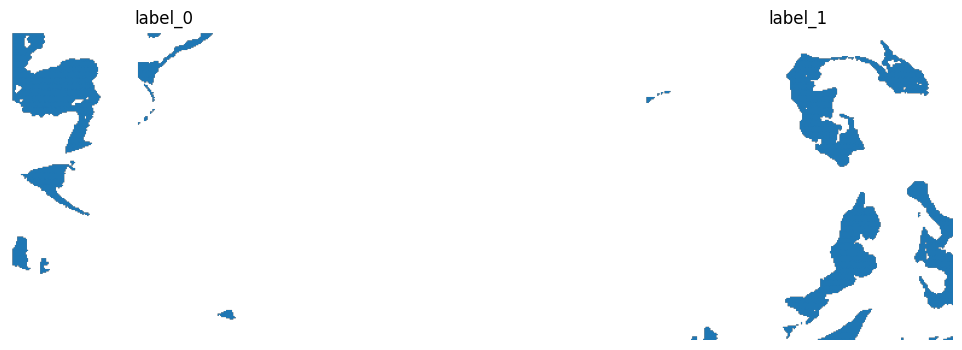

Legend
image_0: sentinel_aws_sentinel-2-l2a_2019-04-12_0_chip.tif
image_1: sentinel_aws_sentinel-2-l2a_2019-04-12_1_chip.tif
---
label_0: sentinel_aws_sentinel-2-l2a_2019-04-12_0_chip_lab.tif
label_1: sentinel_aws_sentinel-2-l2a_2019-04-12_1_chip_lab.tif


In [69]:
plotting.plot_chip_and_label_pairs(
    res, bands=config["download"]["data_sources"][0]["bands"], samples=10,
    chip_suffix=chip_args["chip_suffix"],
    chip_label_suffix=chip_args["chip_label_suffix"],
)

In [ ]:
# Copyright (c) 2026 Copyright 2024 IBM Corp
# 
# This software is released under the MIT License.
# https://opensource.org/licenses/MIT

